In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

data_dir = '/kaggle/input/datasets/msambare/fer2013'

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_full = datasets.ImageFolder(root=f'{data_dir}/train', transform=transform)
test_dataset = datasets.ImageFolder(root=f'{data_dir}/test', transform=transform)

val_size = int(0.1 * len(train_full))
train_size = len(train_full) - val_size
train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

print(f"Train: {train_size}, Val: {val_size}, Test: {len(test_dataset)}")
print(f"Classes: {train_full.classes}")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

Train: 25839, Val: 2870, Test: 7178
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


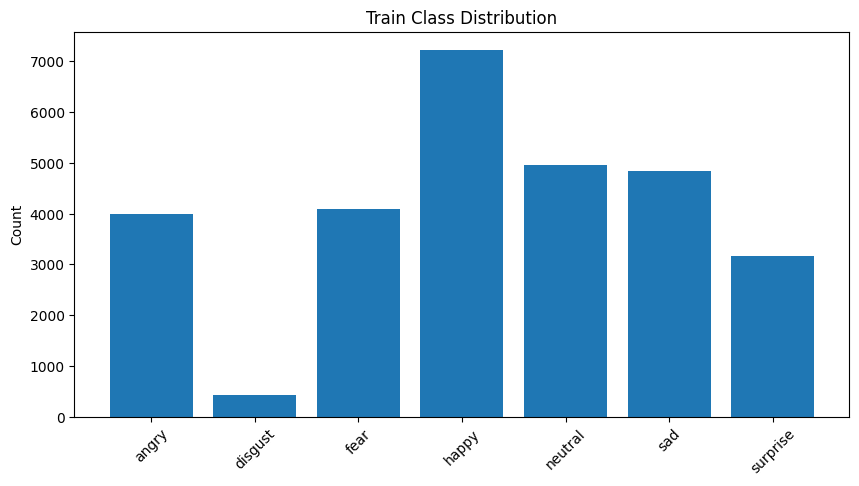

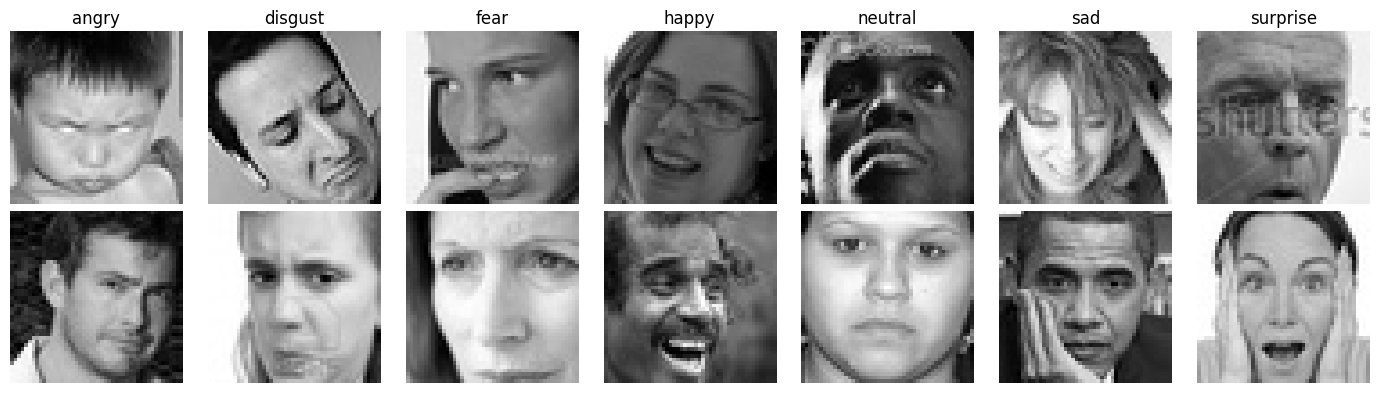

In [10]:
train_labels = [label for _, label in train_full]
class_counts = Counter(train_labels)

plt.figure(figsize=(10, 5))
plt.bar(train_full.classes, [class_counts[i] for i in range(7)])
plt.xticks(rotation=45)
plt.title('Train Class Distribution')
plt.ylabel('Count')
plt.show()

fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for class_idx in range(7):
    indices = [i for i, label in enumerate(train_full.targets) if label == class_idx][:2]
    for row in range(2):
        img, label = train_full[indices[row]]
        axes[row, class_idx].imshow(img.squeeze(), cmap='gray')
        if row == 0:
            axes[row, class_idx].set_title(train_full.classes[class_idx])
        axes[row, class_idx].axis('off')
plt.tight_layout()
plt.show()

In [3]:
test_dataset = datasets.ImageFolder(
    root=f'{data_dir}/test',
    transform=transform
)

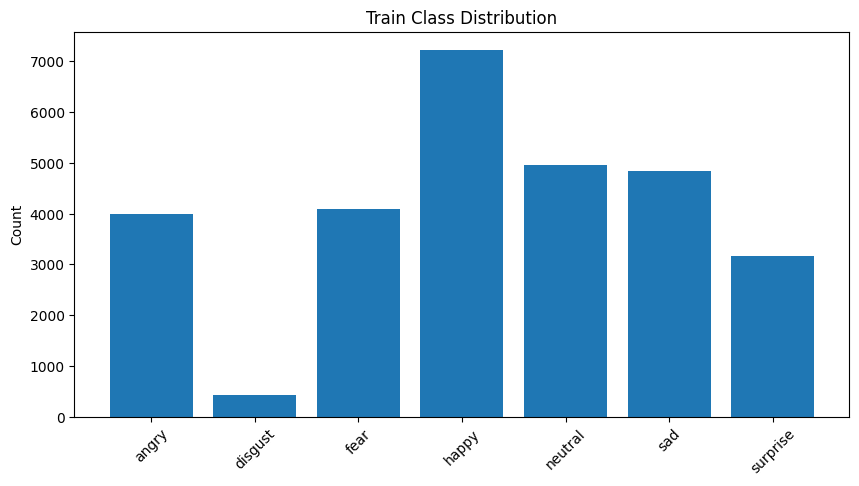

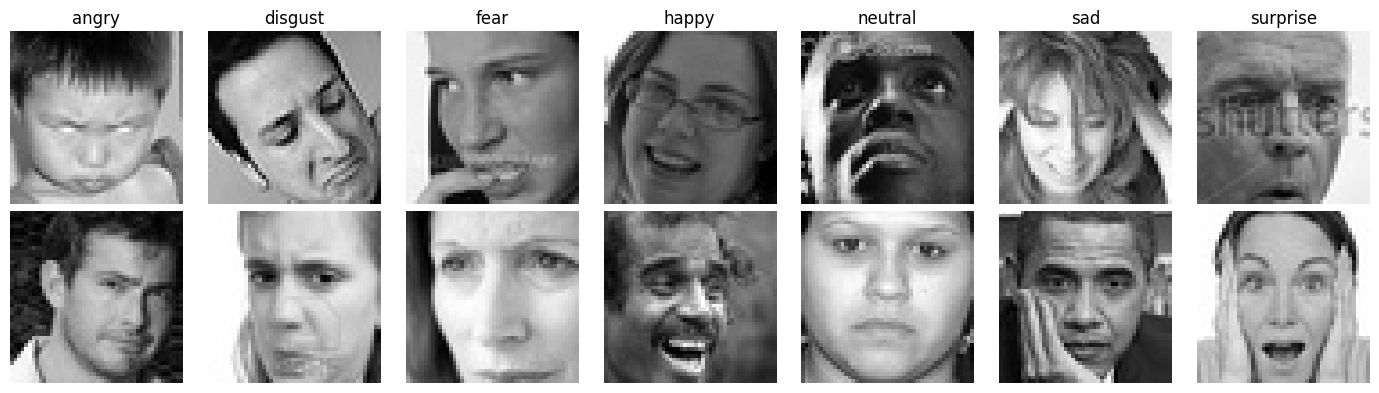

In [4]:
train_labels = [label for _, label in train_dataset]

class_counts = Counter(train_labels)

plt.figure(figsize=(10, 5))
plt.bar(train_dataset.classes, [class_counts[i] for i in range(7)])
plt.xticks(rotation=45)
plt.title('Train Class Distribution')
plt.ylabel('Count')
plt.show()




fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for class_idx in range(7):
    # Найти примеры этого класса
    indices = [i for i, label in enumerate(train_dataset.targets) if label == class_idx][:2]
    
    for row in range(2):
        img, label = train_dataset[indices[row]]
        axes[row, class_idx].imshow(img.squeeze(), cmap='gray')
        if row == 0:
            axes[row, class_idx].set_title(train_dataset.classes[class_idx])
        axes[row, class_idx].axis('off')

plt.tight_layout()
plt.show()

Используем DataLoader для удобного хранения train и test data

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2   
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2   
)


In [11]:
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # [0,1] → [-1,1]
])

Архитектура CNN (baseline)

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    """
    Baseline CNN: 3 conv блока + 2 FC слоя
    
    Каждый conv блок: Conv2d → BatchNorm → ReLU → MaxPool
    
    Размерности:
    (B, 1, 48, 48) → block1 → (B, 32, 24, 24)
                    → block2 → (B, 64, 12, 12)
                    → block3 → (B, 128, 6, 6)
                    → flatten → (B, 128*6*6) = (B, 4608)
                    → fc1 → (B, 256) → fc2 → (B, 7)
    """
    def __init__(self, num_classes=7):
        super().__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),    # 48 → 24
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),    # 24 → 12
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),    # 12 → 6
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.classifier(x)
        return x                     # logits (без softmax!)

# Проверка размерностей
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)

dummy = torch.randn(2, 1, 48, 48).to(device)
out = model(dummy)
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}")  # должно быть (2, 7)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

Input:  torch.Size([2, 1, 48, 48])
Output: torch.Size([2, 7])

Parameters: 1,274,823


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

NUM_EPOCHS = 25

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    
    return running_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
    
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.3f}")

print(f"\nBest Val Accuracy: {best_val_acc:.3f}")

Epoch  1/25 | Train Loss: 1.6204, Acc: 0.362 | Val Loss: 1.3966, Acc: 0.460
Epoch  2/25 | Train Loss: 1.4243, Acc: 0.451 | Val Loss: 1.2918, Acc: 0.499
Epoch  6/25 | Train Loss: 1.2204, Acc: 0.532 | Val Loss: 1.2087, Acc: 0.531
Epoch  7/25 | Train Loss: 1.1899, Acc: 0.544 | Val Loss: 1.1642, Acc: 0.553


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load('best_model.pth'))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Accuracy: {test_acc:.3f}\n")

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

class_names = train_full.classes

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()